In [2]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\modas\Desktop\AENEXZ\India House Price Prediction Dataset\house_price_dataset_india_12k.csv"
df = pd.read_csv(file_path)

df.head()

,House_ID,City,Locality_Tier,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,...,Furnishing,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
0,1,Hyderabad,Mid,3,4,957.3,809.1,11,15,8,...,Semi-Furnished,1,0,2.44,20.76,1.77,3.52,32.4,7736451,8082
1,2,Bangalore,Budget,2,3,883.3,711.7,13,16,13,...,Semi-Furnished,1,0,0.48,17.56,2.82,4.86,66.3,5771877,6534
2,3,Pune,Premium,3,4,1331.5,1087.1,13,15,7,...,Unfurnished,1,1,2.76,9.73,0.20,1.75,23.3,14688106,11031
3,4,Mumbai,Premium,3,4,997.6,801.0,7,19,10,...,Semi-Furnished,1,1,1.12,13.15,0.27,0.61,18.8,19094254,19140
4,5,Pune,Mid,2,2,967.6,707.6,5,16,6,...,Unfurnished,1,1,2.46,14.07,3.34,3.93,41.0,7592420,7847


In [3]:
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("--- FIRST 5 ROWS ---")
display(df.head())

print("\n--- DATASET SUMMARY (INFO) ---")
df.info()

Dataset Dimensions: 12000 rows, 21 columns

--- FIRST 5 ROWS ---


,House_ID,City,Locality_Tier,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,...,Furnishing,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
0,1,Hyderabad,Mid,3,4,957.3,809.1,11,15,8,...,Semi-Furnished,1,0,2.44,20.76,1.77,3.52,32.4,7736451,8082
1,2,Bangalore,Budget,2,3,883.3,711.7,13,16,13,...,Semi-Furnished,1,0,0.48,17.56,2.82,4.86,66.3,5771877,6534
2,3,Pune,Premium,3,4,1331.5,1087.1,13,15,7,...,Unfurnished,1,1,2.76,9.73,0.20,1.75,23.3,14688106,11031
3,4,Mumbai,Premium,3,4,997.6,801.0,7,19,10,...,Semi-Furnished,1,1,1.12,13.15,0.27,0.61,18.8,19094254,19140
4,5,Pune,Mid,2,2,967.6,707.6,5,16,6,...,Unfurnished,1,1,2.46,14.07,3.34,3.93,41.0,7592420,7847



--- DATASET SUMMARY (INFO) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   House_ID                   12000 non-null  int64  
 1   City                       12000 non-null  object 
 2   Locality_Tier              12000 non-null  object 
 3   BHK                        12000 non-null  int64  
 4   Bathrooms                  12000 non-null  int64  
 5   Super_Area_sqft            12000 non-null  float64
 6   Carpet_Area_sqft           12000 non-null  float64
 7   Floor_No                   12000 non-null  int64  
 8   Total_Floors               12000 non-null  int64  
 9   Property_Age_years         12000 non-null  int64  
 10  Parking                    12000 non-null  int64  
 11  Furnishing                 12000 non-null  object 
 12  Lift                       12000 non-null  int64  
 13  Gated_Society 

In [4]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Missing values per column:
No missing values found!

Number of duplicate rows: 0


In [5]:
carpet_vs_super = df[df['Carpet_Area_sqft'] > df['Super_Area_sqft']]
print(f"Rows where Carpet Area > Super Area: {len(carpet_vs_super)}")

floor_consistency = df[df['Floor_No'] > df['Total_Floors']]
print(f"Rows where Floor Number > Total Floors: {len(floor_consistency)}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('House_ID')
negative_counts = (df[numeric_cols] < 0).sum().sum()
print(f"Total instances of negative values in numeric columns: {negative_counts}")

Rows where Carpet Area > Super Area: 0
Rows where Floor Number > Total Floors: 0
Total instances of negative values in numeric columns: 0


In [6]:
df.columns = df.columns.str.strip().str.lower()

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].str.strip()

print("Standardized Column Headers:")
print(df.columns.tolist())

print("\nUnique categories check:")
for col in categorical_cols:
    print(f"{col.capitalize()}: {df[col].unique()}")

Standardized Column Headers:
['house_id', 'city', 'locality_tier', 'bhk', 'bathrooms', 'super_area_sqft', 'carpet_area_sqft', 'floor_no', 'total_floors', 'property_age_years', 'parking', 'furnishing', 'lift', 'gated_society', 'distance_to_metro_km', 'distance_to_citycenter_km', 'nearby_school_km', 'nearby_hospital_km', 'crime_rate_index', 'market_price_inr', 'price_per_sqft_inr']

Unique categories check:
City: ['Hyderabad' 'Bangalore' 'Pune' 'Mumbai' 'Nagpur']
Locality_tier: ['Mid' 'Budget' 'Premium']
Furnishing: ['Semi-Furnished' 'Unfurnished' 'Fully-Furnished']


In [7]:
print("Outliers identified per numeric attribute (IQR Method):")
for col in df.select_dtypes(include=[np.number]).columns.drop('house_id'):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f" - {col}: {len(outliers)} rows out of bounds")

Outliers identified per numeric attribute (IQR Method):
 - bhk: 172 rows out of bounds
 - bathrooms: 571 rows out of bounds
 - super_area_sqft: 357 rows out of bounds
 - carpet_area_sqft: 380 rows out of bounds
 - floor_no: 98 rows out of bounds
 - total_floors: 20 rows out of bounds
 - property_age_years: 36 rows out of bounds
 - parking: 0 rows out of bounds
 - lift: 910 rows out of bounds
 - gated_society: 0 rows out of bounds
 - distance_to_metro_km: 71 rows out of bounds
 - distance_to_citycenter_km: 37 rows out of bounds
 - nearby_school_km: 28 rows out of bounds
 - nearby_hospital_km: 52 rows out of bounds
 - crime_rate_index: 14 rows out of bounds
 - market_price_inr: 545 rows out of bounds
 - price_per_sqft_inr: 332 rows out of bounds


In [8]:
df.to_csv('cleaned_house_price_dataset_india.csv', index=False)
print("The cleaned dataset has been successfully exported to 'cleaned_house_price_dataset_india.csv'!")

The cleaned dataset has been successfully exported to 'cleaned_house_price_dataset_india.csv'!


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('cleaned_house_price_dataset_india.csv')

X = df.drop(columns=['house_id', 'locality_tier'])
y = df['locality_tier']

X = pd.get_dummies(X, columns=['city', 'furnishing'], drop_first=True)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Pre-processing complete!")
print(f"Target Classes: {list(label_encoder.classes_)}")

Pre-processing complete!
Target Classes: ['Budget', 'Mid', 'Premium']


In [20]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
acc_log = accuracy_score(y_test, y_pred_log)

print("--- Logistic Regression Results ---")
print(f"Classification Accuracy: {acc_log * 100:.2f}%")

--- Logistic Regression Results ---
Classification Accuracy: 97.00%


In [22]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("--- Decision Tree Results ---")
print(f"Classification Accuracy: {acc_dt * 100:.2f}%")


--- Decision Tree Results ---
Classification Accuracy: 91.00%


In [23]:
classification_summary = pd.DataFrame({
    'Classification Model': ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors (KNN)'],
    'Accuracy Score': [f"{acc_log * 100:.2f}%", f"{acc_dt * 100:.2f}%", f"{acc_knn * 100:.2f}%"]
}).sort_values(by='Accuracy Score', ascending=False)

print("\n==== CLASSIFICATION ACCURACY BENCHMARK ====")
display(classification_summary)

print("\n==== LOGISTIC REGRESSION REPORT ====")
print(classification_report(y_test, y_pred_log, target_names=label_encoder.classes_))


==== CLASSIFICATION ACCURACY BENCHMARK ====


,Classification Model,Accuracy Score
0,Logistic Regression,97.00%
1,Decision Tree,91.00%
2,K-Nearest Neighbors (KNN),76.42%



==== LOGISTIC REGRESSION REPORT ====
              precision    recall  f1-score   support

      Budget       0.96      0.96      0.96       619
         Mid       0.97      0.97      0.97      1193
     Premium       0.98      0.98      0.98       588

    accuracy                           0.97      2400
   macro avg       0.97      0.97      0.97      2400
weighted avg       0.97      0.97      0.97      2400



In [24]:
X_reg = df.drop(columns=['house_id', 'market_price_inr', 'price_per_sqft_inr'])
y_reg = df['market_price_inr']

X_reg = pd.get_dummies(X_reg, columns=['city', 'locality_tier', 'furnishing'], drop_first=True)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Regression data preparation complete!")
print(f"Training features shape: {X_train_reg.shape}")
print(f"Testing features shape: {X_test_reg.shape}")

Regression data preparation complete!
Training features shape: (9600, 23)
Testing features shape: (2400, 23)


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_train_simple = X_train_reg[['super_area_sqft']]
X_test_simple = X_test_reg[['super_area_sqft']]

simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_train_reg)

y_pred_simple = simple_lr.predict(X_test_simple)

rmse_simple = np.sqrt(mean_squared_error(y_test_reg, y_pred_simple))
r2_simple = r2_score(y_test_reg, y_pred_simple)

print("--- Simple Linear Regression Results ---")
print(f"Intercept (beta_0): ₹{simple_lr.intercept_:.2f}")
print(f"Coefficient for Super Area (beta_1): {simple_lr.coef_[0]:.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse_simple:,.2f}")
print(f"R² Score (Variance Explained): {r2_simple:.4f}")

--- Simple Linear Regression Results ---
Intercept (beta_0): ₹-2750609.55
Coefficient for Super Area (beta_1): 12737.72
Root Mean Squared Error (RMSE): ₹4,504,625.40
R² Score (Variance Explained): 0.5427


In [27]:
multi_lr = LinearRegression()
multi_lr.fit(X_train_reg, y_train_reg)

y_pred_multi = multi_lr.predict(X_test_reg)

rmse_multi = np.sqrt(mean_squared_error(y_test_reg, y_pred_multi))
r2_multi = r2_score(y_test_reg, y_pred_multi)

print("--- Multi-Linear Regression Results ---")
print(f"Intercept ($\beta_0$): ₹{multi_lr.intercept_:.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse_multi:,.2f}")
print(f"R² Score (Variance Explained): {r2_multi:.4f}")

--- Multi-Linear Regression Results ---
Intercept (eta_0$): ₹-1779081.64
Root Mean Squared Error (RMSE): ₹1,939,826.63
R² Score (Variance Explained): 0.9152


In [28]:
regression_summary = pd.DataFrame({
    'Metric': ['Root Mean Squared Error (RMSE)', 'R² Score (Variance Score)'],
    'Simple Linear Regression': [f"₹{rmse_simple:,.2f}", f"{r2_simple:.4f}"],
    'Multi-Linear Regression': [f"₹{rmse_multi:,.2f}", f"{r2_multi:.4f}"]
})

print("\n==== REGRESSION MODEL BENCHMARK ====")
display(regression_summary)

predictions_snapshot = pd.DataFrame({
    'Actual Price (INR)': y_test_reg.values,
    'Simple LR Prediction': y_pred_simple,
    'Multi-LR Prediction': y_pred_multi
}).round(2)

print("\n==== SAMPLE PROPERTY PREDICTIONS VIEW ====")
display(predictions_snapshot.head(10))


==== REGRESSION MODEL BENCHMARK ====


,Metric,Simple Linear Regression,Multi-Linear Regression
0,Root Mean Squared Error (RMSE),"₹4,504,625.40","₹1,939,826.63"
1,R² Score (Variance Score),0.5427,0.9152



==== SAMPLE PROPERTY PREDICTIONS VIEW ====


,Actual Price (INR),Simple LR Prediction,Multi-LR Prediction
0,4974421,7763104.17,3976876.54
1,5558515,11144968.71,5554228.19
2,14959629,19195207.48,15597210.48
3,1562114,3721425.76,-1976030.74
4,3745098,4135401.64,2492820.79
5,4684920,9960360.80,4187967.44
6,8548652,9996026.41,9114596.15
7,12848734,14772671.24,13811366.75
8,1586382,3927776.81,-2781359.14
9,29420791,21824272.79,26101161.18


In [29]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('cleaned_house_price_dataset_india.csv')

features_for_clustering = ['super_area_sqft', 'market_price_inr', 'bhk', 'distance_to_citycenter_km']
X_cluster = df[features_for_clustering]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("Clustering features prepared and scaled successfully!")
print(f"Data shape for clustering: {X_cluster_scaled.shape}")

Clustering features prepared and scaled successfully!
Data shape for clustering: (12000, 4)


Elbow plot generated and saved as 'kmeans_elbow_plot.png'!


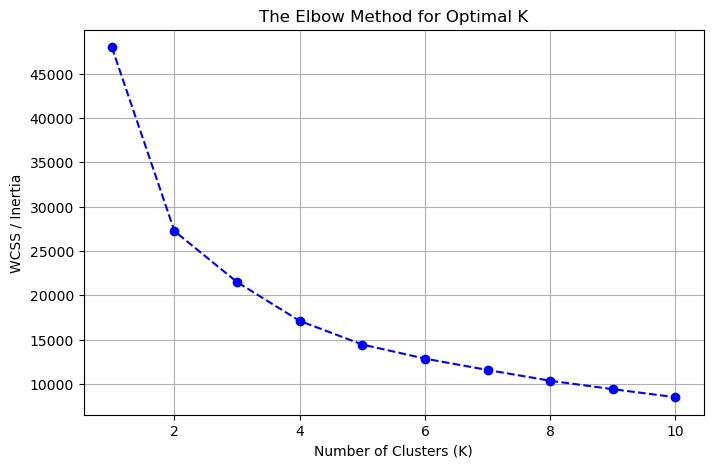

In [30]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.grid(True)
plt.savefig('kmeans_elbow_plot.png')
print("Elbow plot generated and saved as 'kmeans_elbow_plot.png'!")

In [31]:
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

df['property_cluster'] = kmeans_model.fit_predict(X_cluster_scaled)

print("K-Means clustering complete! Labels assigned to dataset.")

K-Means clustering complete! Labels assigned to dataset.


In [32]:
cluster_profile = df.groupby('property_cluster')[features_for_clustering].mean()

cluster_profile.columns = ['Avg Super Area (sqft)', 'Avg Market Price (INR)', 'Avg BHK', 'Avg Distance to City Center (km)']

print("\n==== K-MEANS PROPERTY CLUSTER PROFILES ====")
display(cluster_profile.round(2))

print("\nProperty distribution across clusters:")
print(df['property_cluster'].value_counts())


==== K-MEANS PROPERTY CLUSTER PROFILES ====


,Avg Super Area (sqft),Avg Market Price (INR),Avg BHK,Avg Distance to City Center (km)
property_cluster,,,,
0,1677.68,21469870.65,3.85,10.61
1,741.75,5736672.32,1.59,18.00
2,1082.62,11028792.90,2.52,11.16



Property distribution across clusters:
property_cluster
1    5305
2    4954
0    1741
Name: count, dtype: int64


In [35]:
import pandas as pd

actual_comparison_data = {
    'Algorithm': ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors (KNN)'],
    'Accuracy': ['97.00%', '91.00%', '76.42%'],
    'F1 Score': [0.97, 0.91, 0.76]
}

df_actual_comparison = pd.DataFrame(actual_comparison_data)

print("==== CLASSIFICATION MODEL COMPARISON ====")
display(df_actual_comparison)

==== CLASSIFICATION MODEL COMPARISON ====


,Algorithm,Accuracy,F1 Score
0,Logistic Regression,97.00%,0.97
1,Decision Tree,91.00%,0.91
2,K-Nearest Neighbors (KNN),76.42%,0.76
